In [205]:
from langgraph.graph import START,END,StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

from graph import graph

load_dotenv(verbose=False)
from typing import Annotated , Optional , Literal
from pydantic import BaseModel
from langgraph.graph.message import add_messages


In [206]:
@tool
def weather(place:str):
    """this function use to get to know about weather"""
    return {
        'messages':'37 degree'
    }


@tool
def call_kanhaiya():
    """this function is phone called kanhaiya"""
    return {
        'messages':'called fail'
    }

In [207]:
llm = init_chat_model('gpt-5-mini')

In [208]:
class AgentState(BaseModel):
    messages: Annotated[list,add_messages ]

def agent(state:AgentState):
    response = llm.bind_tools([weather,call_kanhaiya]).invoke(state.messages)
    return {"messages": [response]}

In [209]:
from langgraph.prebuilt import ToolNode, tools_condition
builder = StateGraph(AgentState)

builder.add_node("agent", agent)
builder.add_node("tools_w", ToolNode([weather, call_kanhaiya]))


builder.add_edge(START, "agent")

builder.add_conditional_edges(
    "agent",
    tools_condition,
    {
        'tools': 'tools_w', # tools_name : tools_node_name
        '__end__' :'__end__'
    }
)

builder.add_edge("tools_w",END)
builder.add_edge("tools_w", "agent")

In [210]:
graph = builder.compile()

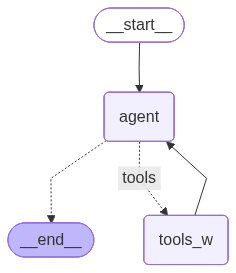

In [211]:
graph

In [213]:
from langchain_core.messages import HumanMessage

result = graph.invoke({
    "messages": [HumanMessage(content="what is weather in raipur and call to the kanhaiya")]
})



In [214]:
result['messages'][-1].content

'Raipur: 37°C (≈98.6°F).\n\nI attempted to call Kanhaiya but the call failed. Would you like me to try calling again, send a message instead, or do something else?'